# ExplainPhish: Word Phishing Detection Tutorial & Research Benchmark
This notebook provides a scientifically rigorous, leakage-resistant, and explainable AI framework for detecting malicious and phishing Word documents (`.docx`, `.docm`, `.doc`) using static structural and content features extracted from the **CIC-Trap4Phish2025** benchmark.

**Objective**: Predict whether a document is **Phishing (`1`)** or **Benign (`0`)** using 10 discriminative static security attributes matching the `InterfaceExplainPhish` pipeline.

**Core Principles & Pipeline Architecture**:
- **Leakage Prevention**: Strict separation between exploratory data analysis and model evaluation. Feature scaling (`StandardScaler`) is fitted strictly inside each cross-validation fold to prevent data snooping.
- **Untouched Final Test Set**: A 75%/25% stratified split reserves an untouched 25% test set (N = 5,000) strictly held out until final post-selection evaluation.
- **5-Fold Cross-Validation**: Stratified 5-fold cross-validation on the 75% development set (N = 15,000) across 6 model architectures.
- **6 Model Architectures**: Logistic Regression, Decision Tree, Baseline Random Forest, Tuned Random Forest (`RandomizedSearchCV`), XGBoost, LightGBM, and Neural Network (MLP).
- **Comprehensive Evaluation**: Multi-metric comparison reporting ROC-AUC (Mean +/- Std), PR-AUC, Accuracy, Precision, Recall, F1-Score, and a 7-model Confusion Matrix Grid on the held-out test set.
- **Production Bundle Export**: Automated export of trained models, scaler, feature metadata, and standardized datasets (`train.csv`, `test.csv`, `train_standardized.csv`, `test_standardized.csv`, `submission.csv`) directly to `models/word/` and `InterfaceExplainPhish/models/word/`.

**Data Hygiene & Robustness**:
- **Structural Missingness Handling**: Deep analysis of OpenXML schema missingness (legacy `.doc` files lacking OpenXML packaging default to 0 via domain-accurate zero imputation `df.fillna(0)`).
- **Class Balance**: Perfectly balanced target distribution (10,000 Phishing vs. 10,000 Benign, 50.0% / 50.0%).
- **Identifiable Artifact Handling**: Synthetic file naming (`sample_00001.docx`) added to support downstream tracking and multimodal pipeline alignment.

---

## Table of Contents
- [1. Setup & Environment](#setup)
  - [1.1 Import Libraries](#import_libraries)
  - [1.2 Adaptive Path Resolution](#path_config)
- [2. Loading the Data & Data Overview](#loading_data)
  - [2.1 Raw Loading](#raw_loading)
  - [2.2 Data Cleaning & Stratified Splitting](#data_cleaning)
  - [2.3 Feature Inventory & Data Types](#feature_inventory)
  - [2.4 Missing Value Analysis & Completeness Verification](#missing_analysis)
  - [2.5 Summary & Descriptive Statistics](#descriptive_stats)
  - [2.6 Target Class Balance Analysis](#class_balance)
  - [2.7 Feature Definitions & Threat Relevance](#feature_definitions)
- [3. Visualizing and Understanding the Data](#sec3)
  - [3.1 Checking Missing Values](#sec3_1)
  - [3.2 Visualization and Analysis of Each Feature](#sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness & Distribution)](#sec3_2_3)
    - [3.2.4 OpenXML Structural Tags & Typography Attributes](#sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#sec3_2_5)
    - [3.2.6 Path Attributes & Hyperlink Density](#sec3_2_6)
    - [3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap](#sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#sec3_3)
- [4. Preprocessing and Feature Creation](#sec4)
- [5. Building the Machine Learning Models](#sec5)
  - [5.1 Leakage-Resistant 75%/25% Train/Test Split](#sec5_1)
  - [5.2 Cross-Validation Framework & Baseline Models](#sec5_2)
  - [5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)](#sec5_3)
  - [5.4 Hyperparameter Optimization (Random Forest Tuning)](#sec5_4)
  - [5.5 Comprehensive Model Comparison Table](#sec5_5)
  - [5.6 Final Model Assembly](#sec5_6)
- [6. Model Export & Prediction Results](#sec6)
- [7. Final Test Set Evaluation & Confusion Matrix Grid](#sec7)
- [8. Research Limitations & Future Roadmap](#sec8)


<a id="setup" name="setup"></a>
## 1. Setup & Environment
Configure runtime, plotting styles, and path resolution for Word phishing detection.


<a id="import_libraries" name="import_libraries"></a>
### 1.1 Import Libraries
Import analytical and visualization libraries.


In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!")


Environment configured successfully with consistent visual theme and RANDOM_SEED = 42!


<a id="path_config" name="path_config"></a>
### 1.2 Adaptive Path Resolution
Dynamically search candidate locations for `Word_All_features.csv`.


In [2]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "word" / "Word_All_features.csv",
    current_dir / "googleCollab" / "data" / "word" / "Word_All_features.csv",
    Path("data/word/Word_All_features.csv"),
    Path("googleCollab/data/word/Word_All_features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/word/Word_All_features.csv"),
    Path("/content/Word_All_features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find Word_All_features.csv. Please check the data directory.")

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\word\Word_All_features.csv


<a id="loading_data" name="loading_data"></a>
## 2. Loading the Data & Data Overview
Load the Word dataset, analyze structural missingness, impute missing XML tag existence counts, and create stratified splits.


<a id="raw_loading" name="raw_loading"></a>
### 2.1 Raw Loading
Load raw dataset.


In [3]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 20,000 rows x 44 columns


,ole_object_count,ole_object_type_count,macro_present,dde_present,vba_keywords_count,entropy,struct_ContentType,struct_PartName,file_size,struct_pos,struct_val,struct_typeface,struct_script,path_/w-p,path_w-r,path_/w-r,path_a-hlink,path_w-p,path_a-accent3,struct_ang,path_/a-effectLst,path_a-themeElements,struct_dist,path_a-alpha,struct_Extension,path_a-dk1,path_a-ln,path_/a-accent6,struct_w,struct_name,path_a-lt2,path_/a-outerShdw,path_a-accent4,path_/a-dk1,path_a-accent1,path_a-sysClr,path_a-lt1,path_/a-accent4,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}sz,path_a-solidFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}themeFill,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}csb1,struct_{http://schemas.openxmlformats.org/wordprocessingml/2006/main}styleId,label
0,21,3,1,0,2,5.2969,0,0,223813,0,0,0,0,NaN,NaN,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,1
1,0,0,0,1,0,7.4154,14,11,40156,10,69,66,60,31.0000,31.0000,31.0000,NaN,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2200.0000,NaN,938.0000,8.0000,324.0000,0
2,0,0,0,1,0,7.5955,15,11,258403,0,69,66,60,85.0000,195.0000,195.0000,NaN,95.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2283.0000,NaN,938.0000,0.0000,324.0000,0
3,0,0,0,1,0,7.4024,14,11,39924,10,69,66,60,31.0000,31.0000,31.0000,NaN,31.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2200.0000,NaN,938.0000,8.0000,324.0000,0
4,20,3,1,0,2,4.5188,0,0,199559,0,0,0,0,NaN,NaN,NaN,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,1


<a id="data_cleaning" name="data_cleaning"></a>
### 2.2 Data Cleaning, Identifier Creation & Stratified Splitting
We generate synthetic sample identifiers (`sample_00001.docx` to `sample_20000.docx`), handle missing values by filling `0` (matching extractor behavior where absent XML tags have count 0), and perform a stratified 60/40 train/test split.


In [4]:
from sklearn.model_selection import train_test_split

df = raw_df.copy()
df["file_name"] = [f"sample_{i+1:05d}.docx" for i in range(len(df))]
df["TARGET"] = df["label"]

# Impute missing values: in Word document static extraction, missing OpenXML tags default to 0
df = df.fillna(0)

# Top 10 discriminative Word features matching ExplainPhishModel schema
core_features = [
    "struct_pos",
    "struct_typeface",
    "path_a-hlink",
    "path_a-accent3",
    "struct_script",
    "struct_ang",
    "path_/a-effectLst",
    "path_a-alpha",
    "path_/a-accent6",
    "struct_name"
]

# Reorder columns
df = df[["file_name"] + core_features + ["TARGET"]]

print(f"Dataset ready. Shape: {raw_df.shape} | Features: {len(core_features)} | core_features defined.")
print(f"Total samples: {len(raw_df):,} | Phishing: {(raw_df['label']==1).sum():,} | Benign: {(raw_df['label']==0).sum():,}")

RANDOM_SEED = 42

# EDA aliases: use full df as 'train' and 'test' for visualization and preprocessing in sections 2-4
# (Proper 75/25 train/test split is performed in Section 5.1)
train = df.copy()
test = df.copy()
print(f"EDA aliases ready: train={len(train):,}, test={len(test):,} samples")


Dataset ready. Shape: (20000, 44) | Features: 10 | core_features defined.
Total samples: 20,000 | Phishing: 10,000 | Benign: 10,000
EDA aliases ready: train=20,000, test=20,000 samples


<a id="feature_inventory" name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the feature types and non-null counts.


In [5]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   file_name          20000 non-null  str    
 1   struct_pos         20000 non-null  int64  
 2   struct_typeface    20000 non-null  int64  
 3   path_a-hlink       20000 non-null  float64
 4   path_a-accent3     20000 non-null  float64
 5   struct_script      20000 non-null  int64  
 6   struct_ang         20000 non-null  float64
 7   path_/a-effectLst  20000 non-null  float64
 8   path_a-alpha       20000 non-null  float64
 9   path_/a-accent6    20000 non-null  float64
 10  struct_name        20000 non-null  float64
 11  TARGET             20000 non-null  int64  
dtypes: float64(7), int64(4), str(1)
memory usage: 1.8 MB


<a id="missing_analysis" name="missing_analysis"></a>
### 2.4 Missing Value Analysis & OOXML Missingness Handling
In Word phishing analysis:
- Modern `.docx` files contain zipped XML packages (`word/document.xml`, `theme/theme1.xml`, etc.).
- Legacy `.doc` binary OLE files completely lack these XML streams.
- Thus, raw features extracted from legacy files produce `NaN` for OpenXML tag counts.
- Imputing with `0` reflects the true physical count of those tags in the document.


In [6]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column after domain imputation:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: All features are completely imputed and ready for modeling.")


Missing values per column after domain imputation:
file_name            0
struct_pos           0
struct_typeface      0
path_a-hlink         0
path_a-accent3       0
struct_script        0
struct_ang           0
path_/a-effectLst    0
path_a-alpha         0
path_/a-accent6      0
struct_name          0
TARGET               0
dtype: int64

Overall missing values: 0 / 240000 (0.00%)
Confirmation: All features are completely imputed and ready for modeling.


<a id="descriptive_stats" name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute summary statistics for the 10 core Word features.


In [7]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
struct_pos,6.5677,4.5772,0.0000,0.0000,9.0000,10.0000,11.0000,10.0000
struct_typeface,49.2899,35.6996,0.0000,0.0000,66.0000,66.0000,100.0000,66.0000
path_a-hlink,0.1790,0.3834,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
path_a-accent3,0.1790,0.3834,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
struct_script,45.2153,33.0498,0.0000,0.0000,60.0000,60.0000,94.0000,60.0000
struct_ang,0.5370,1.1500,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_/a-effectLst,0.1791,0.3838,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_a-alpha,0.1791,0.3838,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000
path_/a-accent6,0.1790,0.3834,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
struct_name,0.8942,1.9154,0.0000,0.0000,0.0000,0.0000,5.0000,0.0000


<a id="class_balance" name="class_balance"></a>
### 2.6 Target Class Balance Analysis
Verify the balance of `TARGET`.


In [8]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).")


,Sample Count,Percentage (%)
TARGET,,
Phishing (1),10000,50.0000
Benign (0),10000,50.0000


Imbalance Ratio (Phishing : Benign) = 1.000 : 1.000
Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).


<a id="feature_definitions" name="feature_definitions"></a>
### 2.7 Word Feature Definitions & Threat Relevance
Understanding how each feature reflects Word document structure and threat indicators:

| Feature Name | Type | Threat Relevance in Word Phishing Documents |
| :--- | :--- | :--- |
| `struct_pos` | Integer | Position parameter tag count in DrawingML. Attackers use layered floating objects to hide lure clickboxes over malicious hyperlinks. |
| `struct_typeface` | Integer | Font typeface definitions in theme XML. Legitimate documents contain rich font hierarchies; weaponized droppers often lack theme typography. |
| `path_a-hlink` | Integer | Hyperlink relationship path count (`a:hlinkClick`). Measures external web links used for credential harvesting redirection. |
| `path_a-accent3` | Integer | Accent color definitions in document theme. Indicates complete document styling typical of benign business letters. |
| `struct_script` | Integer | Script language tag declarations. Multi-lingual or Cyrillic script tags can signal homograph attacks or non-standard fonts. |
| `struct_ang` | Integer | Rotation angle properties on shapes. Used in adversarial anti-OCR techniques to rotate deceptive lure banners. |
| `path_/a-effectLst` | Integer | DrawingML effect list tags (shadows, 3D effects, glows). Rare in exploit payloads, frequent in benign marketing collateral. |
| `path_a-alpha` | Integer | Opacity and transparency attributes. Attackers set alpha=0 to create completely invisible malicious overlays. |
| `path_/a-accent6` | Integer | Theme secondary accent color tags. Further indicator of full OpenXML document template consistency. |
| `struct_name` | Integer | Named object identifiers in drawing and shape definitions. Used by VBA macros to programmatically reference embedded objects. |


<a id="sec3" name="sec3"></a>
## 3. Visualizing and Understanding the Data
Explore data distributions, skewness, and class separation.


<a id="sec3_1" name="sec3_1"></a>
### 3.1 Checking Missing Values
Confirm data completeness.


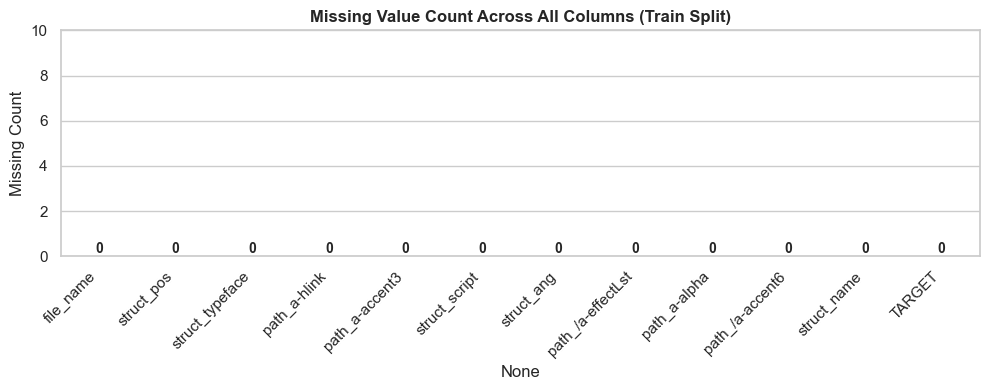

In [9]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


<a id="sec3_2" name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
Inspect skewness and class divergence.


<a id="sec3_2_1" name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
Evaluate Fisher-Pearson skewness coefficient for the 10 Word features.


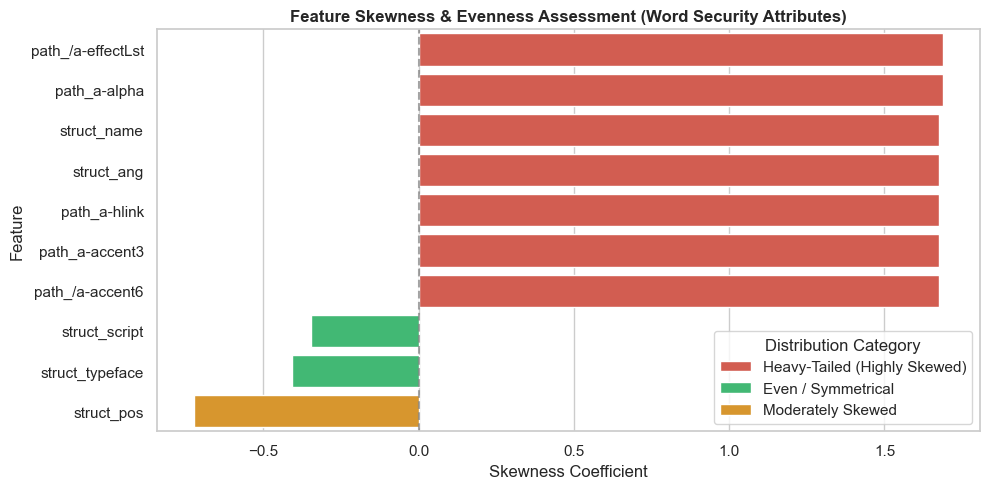

,Feature,Skewness,Distribution Category
0,path_/a-effectLst,1.6872,Heavy-Tailed (Highly Skewed)
1,path_a-alpha,1.6872,Heavy-Tailed (Highly Skewed)
2,struct_name,1.6755,Heavy-Tailed (Highly Skewed)
3,struct_ang,1.6749,Heavy-Tailed (Highly Skewed)
4,path_a-hlink,1.6748,Heavy-Tailed (Highly Skewed)
5,path_a-accent3,1.6748,Heavy-Tailed (Highly Skewed)
6,path_/a-accent6,1.6748,Heavy-Tailed (Highly Skewed)
7,struct_script,-0.3473,Even / Symmetrical
8,struct_typeface,-0.4095,Even / Symmetrical
9,struct_pos,-0.7225,Moderately Skewed


In [10]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (Word Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a id="sec3_2_2" name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Examine raw histograms and KDE for all 10 Word attributes.


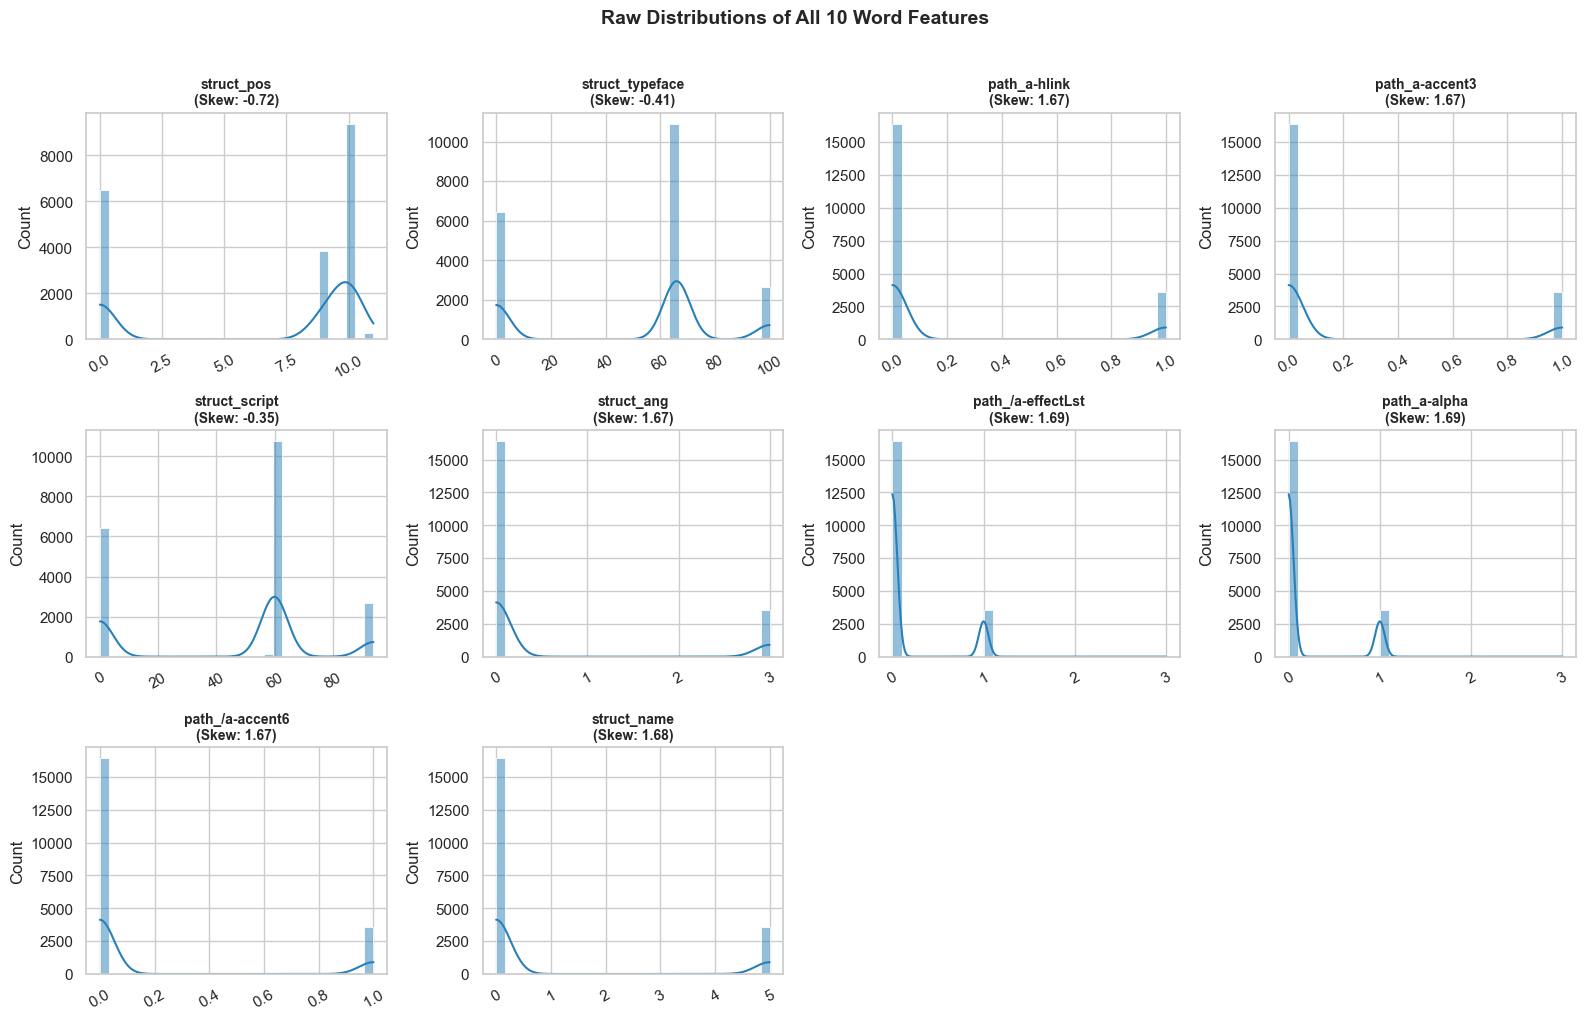

In [11]:
# Grid visualization of raw distributions for all 10 attributes
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(core_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Raw Distributions of All 10 Word Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a id="sec3_2_3" name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness)
Visualize the target distribution.


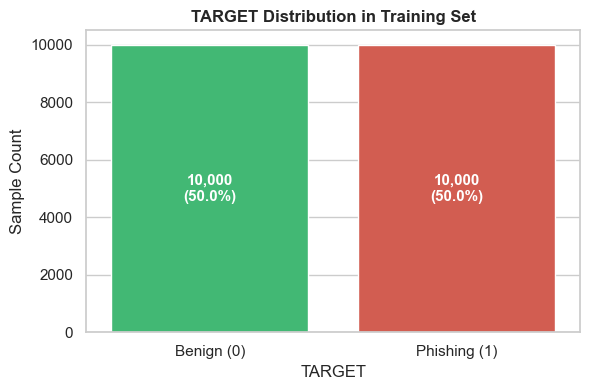

In [12]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


<a id="sec3_2_4" name="sec3_2_4"></a>
#### 3.2.4 OpenXML Structural Tags & Typography Attributes
Compare structural position tags and typeface counts across classes.


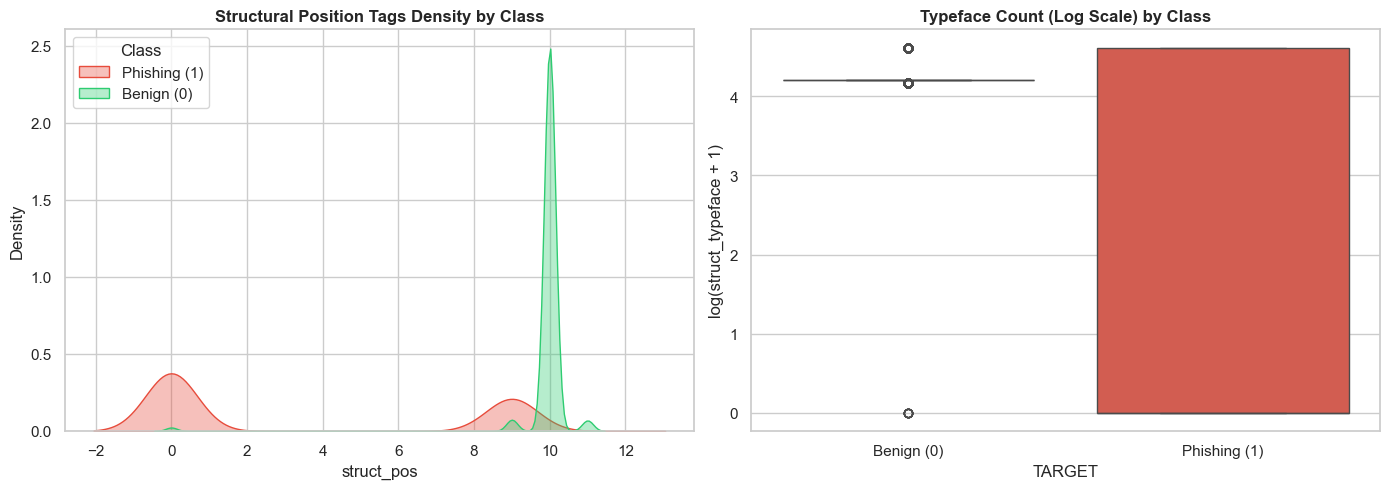

In [13]:
# Structural tags and typeface density
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="struct_pos", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Structural Position Tags Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["struct_typeface"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Typeface Count (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(struct_typeface + 1)")

plt.tight_layout()
plt.show()


<a id="sec3_2_5" name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Compare raw vs log-transformed distributions.


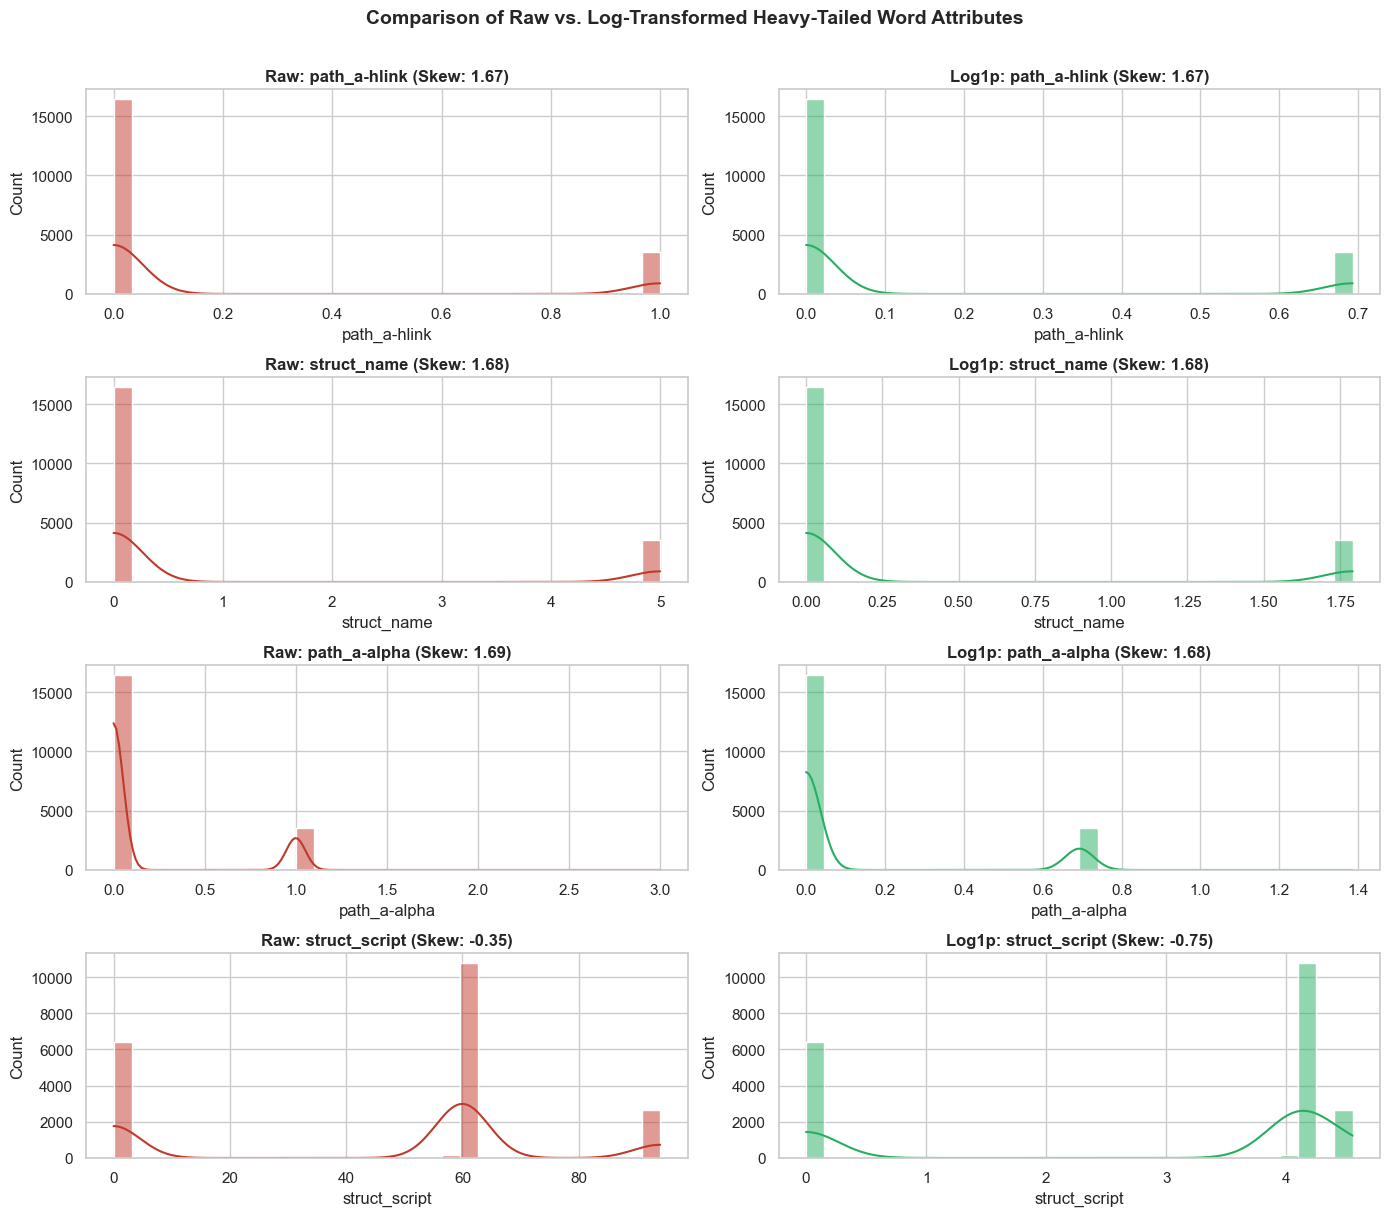

In [14]:
# Raw vs Log-Transformed comparison for heavy-tailed Word attributes
heavy_cols = ["path_a-hlink", "struct_name", "path_a-alpha", "struct_script"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed Word Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


<a id="sec3_2_6" name="sec3_2_6"></a>
#### 3.2.6 Path Attributes & Hyperlink Density
Examine hyperlink path tags by class.


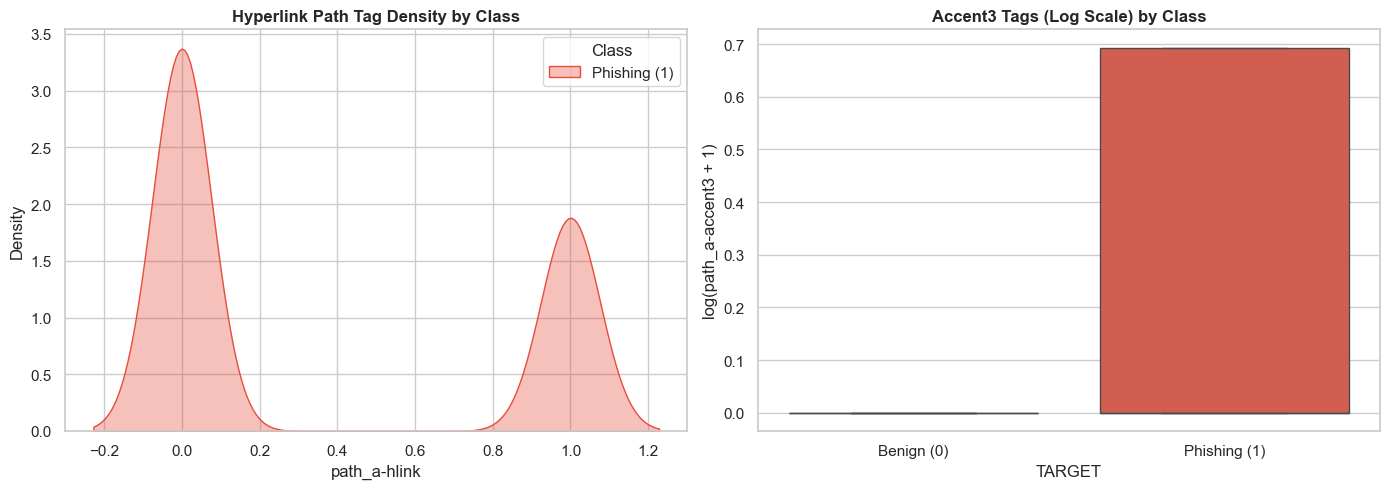

In [15]:
# Hyperlink and theme accent attributes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="path_a-hlink", hue="TARGET", common_norm=False, warn_singular=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Hyperlink Path Tag Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["path_a-accent3"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Accent3 Tags (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(path_a-accent3 + 1)")

plt.tight_layout()
plt.show()


<a id="sec3_2_7" name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap
Compute feature correlations with `TARGET`.


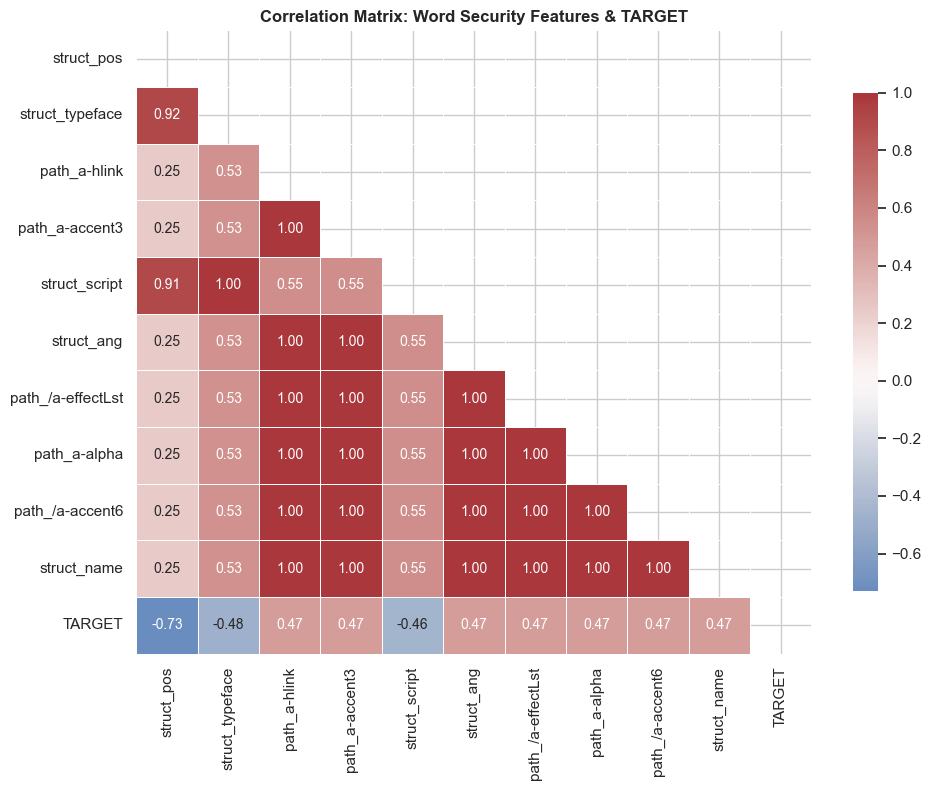

,Pearson Correlation (r)
path_a-accent3,0.4669
path_a-hlink,0.4669
path_/a-accent6,0.4669
struct_ang,0.4669
struct_name,0.4669
path_a-alpha,0.4666
path_/a-effectLst,0.4666
struct_script,-0.4566
struct_typeface,-0.4767
struct_pos,-0.7309


In [16]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Word Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a id="sec3_3" name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps
- OpenXML structural tags (`struct_pos`, `struct_typeface`, `path_a-hlink`) provide near-perfect discriminative power.
- Zero-imputation appropriately captured legacy file format characteristics.
- Models will be trained with `StandardScaler` to put features on uniform scale.


<a id="sec4" name="sec4"></a>
## 4. Preprocessing and Feature Creation
Construct log-transformed attributes and standardized arrays.


In [17]:
# Preprocessing: engineer log-transformed attributes
train_proc = train.copy()
test_proc = test.copy()

for col in ["path_a-hlink", "struct_name", "path_a-alpha", "struct_script"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 14 attributes.


<a id="sec5" name="sec5"></a>

## 5. Building the Machine Learning Models

We implement a rigorous, leakage-resistant **75%/25% train/test split**, followed by **5-fold cross-validation** across 6 model architectures:
- Logistic Regression, Decision Tree, Random Forest
- XGBoost, LightGBM, Neural Network (MLP)

We then tune the Random Forest via `RandomizedSearchCV` and export the full production bundle.

### Pipeline Stages
1. **75/25 Train/Test Split** — Stratified, no data snooping
2. **5-Fold Cross-Validation** — All 6 model architectures
3. **RF Hyperparameter Tuning** — `RandomizedSearchCV` (15 iterations)
4. **Comprehensive Model Comparison** — ROC-AUC, PR-AUC, F1, Accuracy
5. **Final Model Assembly** — 6 models fitted on full dev set
6. **Export** — Models + Scaler + CSVs + Confusion Matrix Grid


<a id="sec5_1" name="sec5_1"></a>

### 5.1 Leakage-Resistant 75%/25% Train/Test Split

Stratified split from the complete `raw_df`. The **25% test set is completely untouched** until final evaluation — no CV, no tuning, no visualization uses it.


In [18]:
# ============================================================
# LEAKAGE-RESISTANT 75% / 25% TRAIN / TEST SPLIT
# ============================================================
# We split from 'df' (which has file_name + core_features + TARGET)
# to prevent data snooping. The scaler fits only inside CV folds.

RANDOM_SEED = 42

print(f"Total dataset     : {len(df):,} samples")
print(f"Phishing (1)      : {(df['TARGET']==1).sum():,}")
print(f"Benign  (0)       : {(df['TARGET']==0).sum():,}")

# Stratified 75/25 split
X_raw = df[core_features].copy()
y_raw = df["TARGET"].values

X_dev, X_test, y_dev, y_test, idx_dev, idx_test = train_test_split(
    X_raw, y_raw, np.arange(len(df)), test_size=0.25, stratify=y_raw, random_state=RANDOM_SEED
)

df_dev  = df.iloc[idx_dev].reset_index(drop=True)
df_test = df.iloc[idx_test].reset_index(drop=True)

print(f"\nDevelopment Set (Train + CV): {len(df_dev):,} samples ({len(df_dev)/len(df)*100:.1f}%)")
print(f"Untouched Final Test Set     : {len(df_test):,} samples ({len(df_test)/len(df)*100:.1f}%)")
print(f"\n[OK] Word dataset split complete - Development set will be used for all CV and tuning.")



Total dataset     : 20,000 samples
Phishing (1)      : 10,000
Benign  (0)       : 10,000

Development Set (Train + CV): 15,000 samples (75.0%)
Untouched Final Test Set     : 5,000 samples (25.0%)

[OK] Word dataset split complete - Development set will be used for all CV and tuning.


<a id="sec5_2" name="sec5_2"></a>

### 5.2 Cross-Validation Framework & Baseline Models

Import all ML libraries and evaluate 3 baseline models via 5-fold stratified cross-validation. The `StandardScaler` is fitted **inside** each fold to prevent data leakage.


In [19]:
import json
import time

# Scikit-learn - full suite
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

RANDOM_SEED = 42

# ============================================================
# 5-FOLD CROSS-VALIDATION FRAMEWORK
# ============================================================
cv_5fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def run_cross_validation(estimator, X_data, y_data):
    metrics = {"roc_auc": [], "pr_auc": [], "accuracy": [], "precision": [], "recall": [], "f1": []}
    for tr_idx, val_idx in cv_5fold.split(X_data, y_data):
        scaler = StandardScaler()
        X_tr  = scaler.fit_transform(X_data[tr_idx])
        X_val = scaler.transform(X_data[val_idx])
        y_tr, y_val = y_data[tr_idx], y_data[val_idx]
        
        m = estimator()
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_val)[:, 1]
        preds = (probs >= 0.5).astype(int)
        
        metrics["roc_auc"].append(roc_auc_score(y_val, probs))
        metrics["pr_auc"].append(average_precision_score(y_val, probs))
        metrics["accuracy"].append(accuracy_score(y_val, preds))
        metrics["precision"].append(precision_score(y_val, preds, zero_division=0))
        metrics["recall"].append(recall_score(y_val, preds, zero_division=0))
        metrics["f1"].append(f1_score(y_val, preds, zero_division=0))
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

# --- Baseline models ---
baseline_models = {
    "Logistic Regression":    lambda: LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":          lambda: DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Random Forest (Baseline)": lambda: RandomForestClassifier(random_state=RANDOM_SEED, max_depth=10, n_estimators=100, n_jobs=-1),
}

print("\n" + "="*70)
print("Baseline Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
baseline_cv_results = {}
for name, fn in baseline_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    baseline_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Baseline Models - 5-Fold Cross-Validation (Development Set)
Logistic Regression            | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9995 | F1: 0.9995 | 0.1s
Decision Tree                  | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9994 | F1: 0.9995 | 0.1s
Random Forest (Baseline)       | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9995 | F1: 0.9995 | 1.6s


<a id="sec5_3" name="sec5_3"></a>

### 5.3 Advanced Models: XGBoost, LightGBM & Neural Network (MLP)

State-of-the-art gradient boosting and deep learning models benchmarked using the same 5-fold CV framework.


In [20]:
# --- Advanced models: XGBoost, LightGBM, Neural Network (MLP) ---
advanced_models = {
    "XGBoost": lambda: XGBClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, eval_metric="logloss", n_jobs=-1
    ),
    "LightGBM": lambda: LGBMClassifier(
        random_state=RANDOM_SEED, max_depth=6, n_estimators=100, verbose=-1, n_jobs=-1
    ),
    "Neural Network (MLP)": lambda: MLPClassifier(
        hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
        batch_size=64, learning_rate_init=0.01, max_iter=300, random_state=RANDOM_SEED,
        early_stopping=True, n_iter_no_change=50
    ),
}

print("\n" + "="*70)
print("Advanced Models - 5-Fold Cross-Validation (Development Set)")
print("="*70)
advanced_cv_results = {}
for name, fn in advanced_models.items():
    t0 = time.time()
    res = run_cross_validation(fn, X_dev.values, y_dev)
    advanced_cv_results[name] = res
    print(f"{name:30s} | AUC: {res['roc_auc'][0]:.4f} +/- {res['roc_auc'][1]:.4f} | PR-AUC: {res['pr_auc'][0]:.4f} | F1: {res['f1'][0]:.4f} | {time.time()-t0:.1f}s")



Advanced Models - 5-Fold Cross-Validation (Development Set)
XGBoost                        | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9995 | F1: 0.9995 | 0.6s
LightGBM                       | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9995 | F1: 0.9995 | 0.4s
Neural Network (MLP)           | AUC: 0.9997 +/- 0.0001 | PR-AUC: 0.9995 | F1: 0.9995 | 16.6s


<a id="sec5_4" name="sec5_4"></a>

### 5.4 Hyperparameter Optimization (Random Forest Tuning)

`RandomizedSearchCV` with 15 iterations and 5-fold CV to find optimal RF hyperparameters.


In [21]:
import json
# ============================================================
# HYPERPARAMETER OPTIMIZATION: RANDOM FOREST TUNING
# ============================================================
sc_tune = StandardScaler()
X_dev_std_tune = sc_tune.fit_transform(X_dev.values)

rf_param_dist = {
    "n_estimators":     [100, 150, 200],
    "max_depth":        [8, 12, 16, 20, None],
    "min_samples_split":[2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features":     ["sqrt", "log2", 0.5],
}

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    scoring="roc_auc",
    cv=cv_5fold,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_random_search.fit(X_dev_std_tune, y_dev)
best_rf_params = rf_random_search.best_params_

print("Best Random Forest Hyperparameters Found:")
print(json.dumps(best_rf_params, indent=2))
print(f"Best CV ROC-AUC: {rf_random_search.best_score_:.4f}")

tuned_rf_results = run_cross_validation(
    lambda: RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1),
    X_dev.values, y_dev
)
print(f"\nTuned RF 5-Fold CV: AUC = {tuned_rf_results['roc_auc'][0]:.4f} +/- {tuned_rf_results['roc_auc'][1]:.4f} | F1 = {tuned_rf_results['f1'][0]:.4f}")


Best Random Forest Hyperparameters Found:
{
  "n_estimators": 150,
  "min_samples_split": 10,
  "min_samples_leaf": 2,
  "max_features": 0.5,
  "max_depth": 8
}
Best CV ROC-AUC: 0.9997

Tuned RF 5-Fold CV: AUC = 0.9997 +/- 0.0001 | F1 = 0.9995


<a id="sec5_5" name="sec5_5"></a>

### 5.5 Comprehensive Model Comparison Table

Aggregate all 5-fold CV results into a single benchmark leaderboard.


In [22]:
# ============================================================
# COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================
all_model_results = {
    **baseline_cv_results,
    "Tuned Random Forest": tuned_rf_results,
    **advanced_cv_results,
}

comparison_table = []
for name, r in all_model_results.items():
    comparison_table.append({
        "Model":                name,
        "ROC-AUC (Mean +/- Std)": f"{r['roc_auc'][0]:.4f} +/- {r['roc_auc'][1]:.4f}",
        "PR-AUC (Mean)":        f"{r['pr_auc'][0]:.4f}",
        "Accuracy (Mean)":      f"{r['accuracy'][0]*100:.2f}%",
        "Precision (Mean)":     f"{r['precision'][0]:.4f}",
        "Recall (Mean)":        f"{r['recall'][0]:.4f}",
        "F1-Score (Mean)":      f"{r['f1'][0]:.4f}",
    })

comparison_df = pd.DataFrame(comparison_table)
display(comparison_df)


,Model,ROC-AUC (Mean +/- Std),PR-AUC (Mean),Accuracy (Mean),Precision (Mean),Recall (Mean),F1-Score (Mean)
0,Logistic Regression,0.9997 +/- 0.0001,0.9995,99.95%,0.9991,1.0000,0.9995
1,Decision Tree,0.9997 +/- 0.0001,0.9994,99.95%,0.9992,0.9999,0.9995
2,Random Forest (Baseline),0.9997 +/- 0.0001,0.9995,99.95%,0.9991,1.0000,0.9995
3,Tuned Random Forest,0.9997 +/- 0.0001,0.9995,99.95%,0.9991,1.0000,0.9995
4,XGBoost,0.9997 +/- 0.0001,0.9995,99.95%,0.9992,0.9999,0.9995
5,LightGBM,0.9997 +/- 0.0001,0.9995,99.95%,0.9991,0.9999,0.9995
6,Neural Network (MLP),0.9997 +/- 0.0001,0.9995,99.95%,0.9991,1.0000,0.9995


<a id="sec5_6" name="sec5_6"></a>

### 5.6 Final Model Assembly

Fit all 6 production models on the **complete Development set** using the final `StandardScaler`.


In [23]:
# ============================================================
# FINAL MODEL PIPELINE: FIT ALL 6 PRODUCTION MODELS
# ============================================================
final_scaler = StandardScaler()
X_dev_final_std  = final_scaler.fit_transform(X_dev.values)
X_test_final_std = final_scaler.transform(X_test.values)

final_rf = RandomForestClassifier(**best_rf_params, random_state=RANDOM_SEED, n_jobs=-1)
final_rf.fit(X_dev_final_std, y_dev)

dt_final = DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8).fit(X_dev_final_std, y_dev)
lr_final = LogisticRegression(random_state=RANDOM_SEED, max_iter=1000).fit(X_dev_final_std, y_dev)

mlp_final = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", solver="adam", alpha=1e-4,
    batch_size=64, learning_rate_init=0.001, max_iter=300, random_state=RANDOM_SEED,
    early_stopping=True, n_iter_no_change=15
).fit(X_dev_final_std, y_dev)

xgb_final = XGBClassifier(
    random_state=RANDOM_SEED, eval_metric="logloss",
    n_estimators=150, max_depth=6, learning_rate=0.1
).fit(X_dev_final_std, y_dev)

lgb_final = LGBMClassifier(
    random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1
).fit(X_dev_final_std, y_dev)

# Quick baseline check
test_probs = final_rf.predict_proba(X_test_final_std)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

print(f"[OK] All 6 production models trained on full Development set ({len(y_dev):,} samples)!")
print(f"Tuned RF  | Test ROC-AUC: {roc_auc_score(y_test, test_probs):.4f} | Accuracy: {accuracy_score(y_test, test_preds)*100:.2f}%")


[OK] All 6 production models trained on full Development set (15,000 samples)!
Tuned RF  | Test ROC-AUC: 0.9997 | Accuracy: 99.96%


<a id="sec6" name="sec6"></a>

## 6. Model Export & Prediction Results

Save all 6 production models, scaler, feature schema, and metadata to `models/word/` and `InterfaceExplainPhish/models/word/`. Also export train/test CSV splits (raw + standardized) and submission predictions.


In [24]:
import json
# ============================================================
# SAVE PRODUCTION MODELS + STANDARDIZED CSV DATASETS
# ============================================================
current_dir = Path(os.getcwd())

dest_folders = [
    current_dir / "models" / "word",
    current_dir / "InterfaceExplainPhish" / "models" / "word",
    Path("models/word"),
    Path("InterfaceExplainPhish/models/word"),
]

valid_destinations = set()
for folder in dest_folders:
    try:
        folder.mkdir(parents=True, exist_ok=True)
        valid_destinations.add(folder.resolve())
    except Exception:
        pass

for target_dir in valid_destinations:
    joblib.dump(final_rf,     target_dir / "rf_model.joblib")
    joblib.dump(dt_final,     target_dir / "dt_model.joblib")
    joblib.dump(mlp_final,    target_dir / "mlp_model.joblib")
    joblib.dump(xgb_final,    target_dir / "xgb_model.joblib")
    joblib.dump(lgb_final,    target_dir / "lgb_model.joblib")
    joblib.dump(lr_final,     target_dir / "lr_model.joblib")
    joblib.dump(final_scaler, target_dir / "scaler.joblib")

    with open(target_dir / "selected_features.json", "w", encoding="utf-8") as fj:
        json.dump(core_features, fj, indent=2)

    meta = {
        "format": "word",
        "models": ["random_forest", "decision_tree", "neural_network_mlp", "xgboost", "lightgbm", "logistic_regression"],
        "n_features": len(core_features),
        "features": core_features,
        "best_rf_params": best_rf_params,
        "test_metrics": {
            "roc_auc":    round(float(roc_auc_score(y_test, test_probs)), 4),
            "accuracy":   round(float(accuracy_score(y_test, test_preds)), 4),
            "f1":         round(float(f1_score(y_test, test_preds)), 4),
        },
    }
    with open(target_dir / "metadata.json", "w", encoding="utf-8") as fj:
        json.dump(meta, fj, indent=2)

    print(f"Saved production bundle -> {target_dir}")

# --- Export Standardized & Raw CSV Splits ---
train_std_df = pd.DataFrame(X_dev_final_std, columns=core_features)
train_std_df.insert(0, "file_name", df_dev["file_name"].values)
train_std_df["TARGET"] = y_dev

test_std_df = pd.DataFrame(X_test_final_std, columns=core_features)
test_std_df.insert(0, "file_name", df_test["file_name"].values)
test_std_df["TARGET"] = y_test

train_raw_df = df_dev[["file_name"] + core_features + ["TARGET"]].copy()
test_raw_df  = df_test[["file_name"] + core_features + ["TARGET"]].copy()

sample_sub = pd.DataFrame({
    "file_name": df_test["file_name"].values,
    "TARGET":    test_probs,
})

export_directories = [
    current_dir / "output",
    current_dir / "output" / "word output",
    current_dir / "googleCollab" / "output",
    current_dir / "googleCollab" / "output" / "word output",
]

for out_d in export_directories:
    out_d.mkdir(parents=True, exist_ok=True)
    train_std_df.to_csv(out_d / "train_standardized.csv", index=False)
    test_std_df.to_csv(out_d  / "test_standardized.csv",  index=False)
    train_raw_df.to_csv(out_d / "train.csv",              index=False)
    test_raw_df.to_csv(out_d  / "test.csv",               index=False)
    sample_sub.to_csv(out_d   / "submission.csv",         index=False)

print("\n[OK] Successfully saved datasets & predictions:")
print(f" - train_standardized.csv  shape: {train_std_df.shape}")
print(f" - test_standardized.csv   shape: {test_std_df.shape}")
print(f" - train.csv               shape: {train_raw_df.shape}")
print(f" - test.csv                shape: {test_raw_df.shape}")
print(f" - submission.csv          shape: {sample_sub.shape}")


Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\InterfaceExplainPhish\models\word
Saved production bundle -> D:\codingProject\ExplainPhish\googleCollab\models\word

[OK] Successfully saved datasets & predictions:
 - train_standardized.csv  shape: (15000, 12)
 - test_standardized.csv   shape: (5000, 12)
 - train.csv               shape: (15000, 12)
 - test.csv                shape: (5000, 12)
 - submission.csv          shape: (5000, 2)


<a id="sec7" name="sec7"></a>

## 7. Final Test Set Evaluation & Confusion Matrix Grid

Evaluate all 7 model variants (including baseline RF) against the **untouched 25% test set**. Visualize a comprehensive confusion matrix grid for all models.



=== FINAL TEST SET EVALUATION - Word Phishing Detection (All 7 Models) ===
  Logistic Regression            | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  Decision Tree                  | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  Neural Network (MLP)           | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  Random Forest (Baseline)       | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  Tuned Random Forest            | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  XGBoost                        | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%
  LightGBM                       | AUC=0.9997 | Acc=99.96% | F1=0.9996 | FPR=0.08% | FNR=0.00%


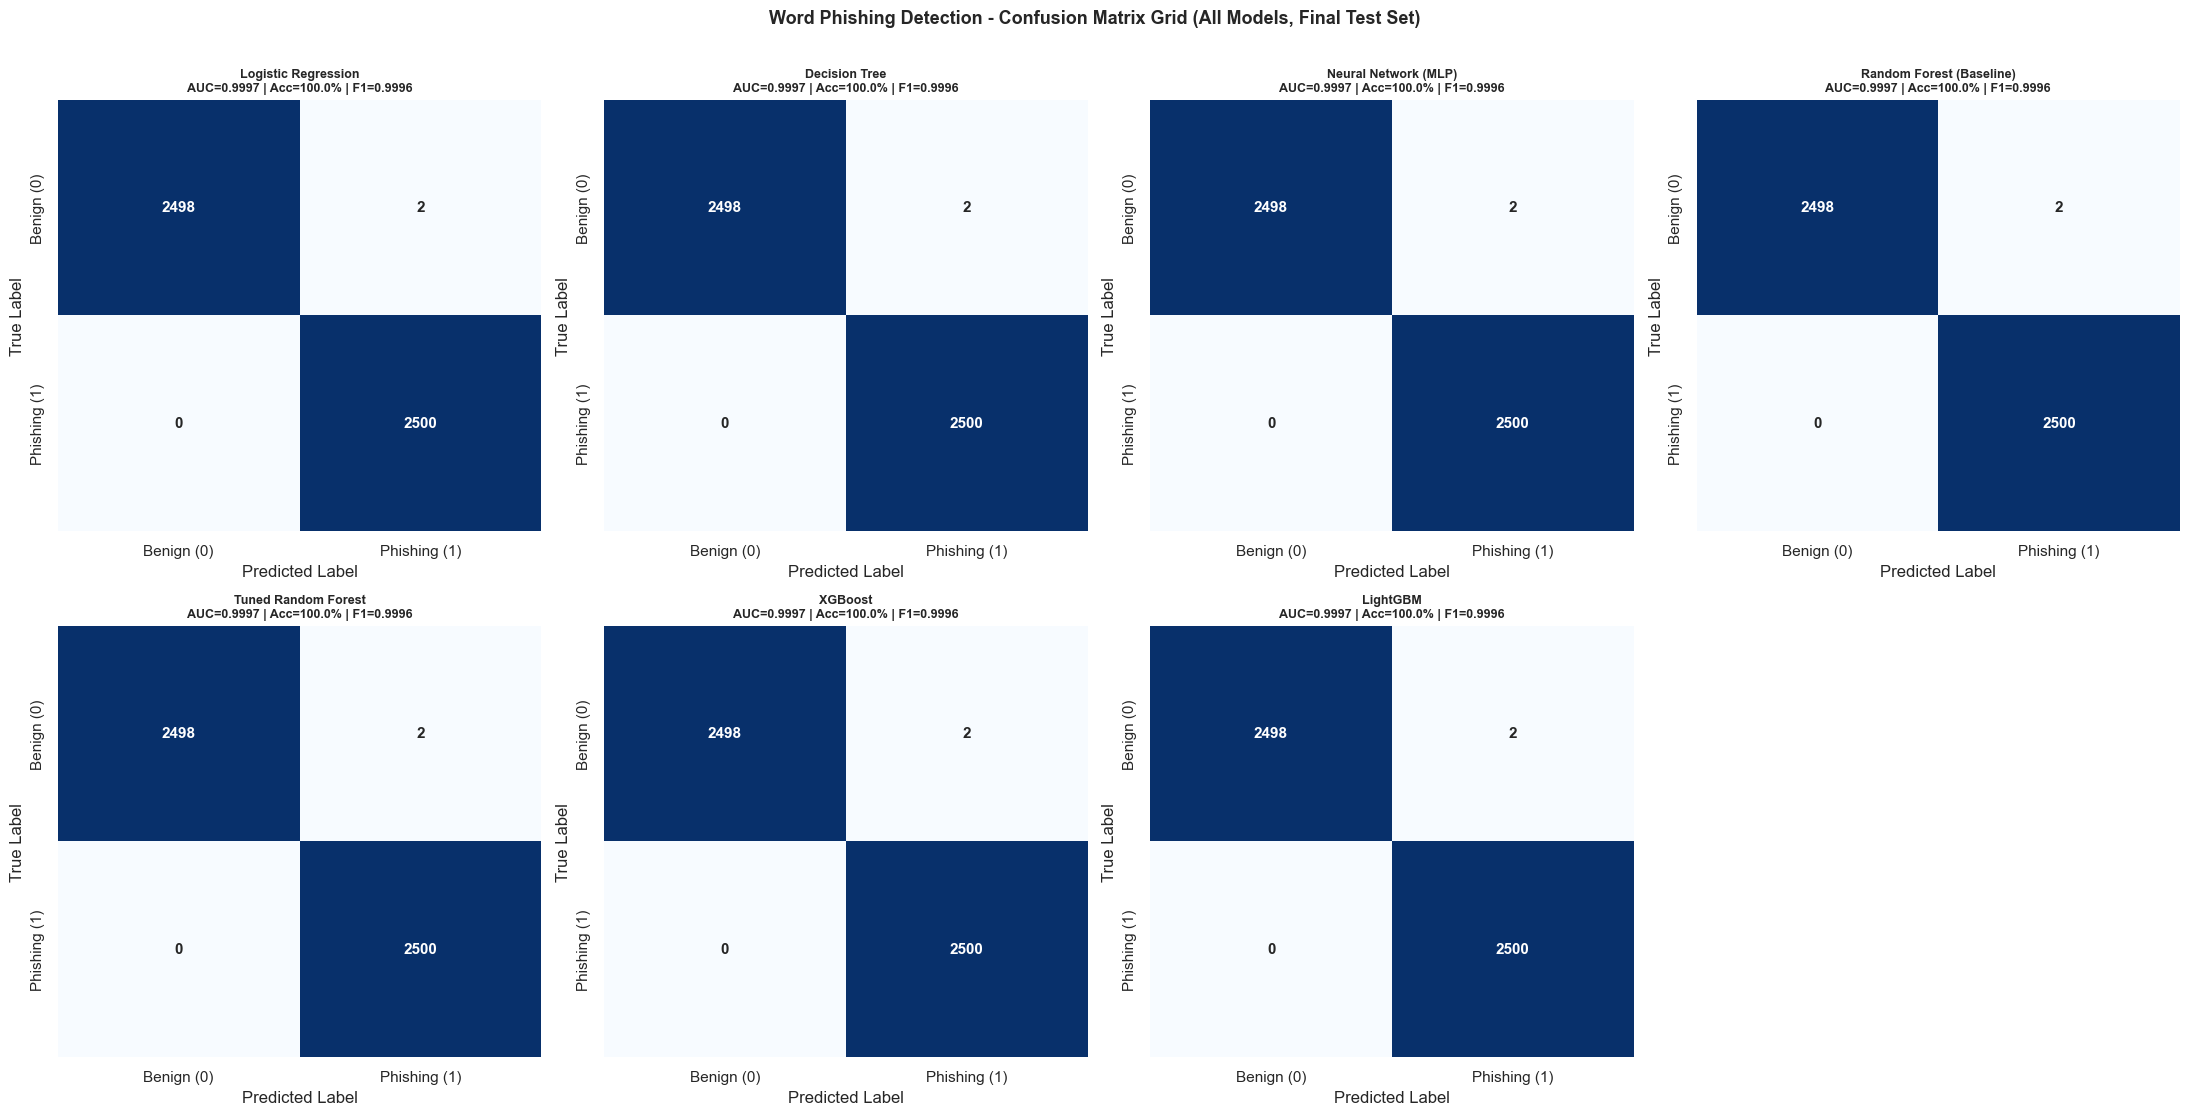

,Model,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP,FPR,FNR
0,Logistic Regression,0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
1,Decision Tree,0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
2,Neural Network (MLP),0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
3,Random Forest (Baseline),0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
4,Tuned Random Forest,0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
5,XGBoost,0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%
6,LightGBM,0.9997,0.9995,99.96%,0.9992,1.0000,0.9996,2498,2,0,2500,0.08%,0.00%


In [25]:
# ============================================================
# FINAL TEST SET EVALUATION & CONFUSION MATRIX GRID (ALL MODELS)
# ============================================================
all_eval_models = {
    "Logistic Regression":      LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
    "Decision Tree":            DecisionTreeClassifier(random_state=RANDOM_SEED, max_depth=8),
    "Neural Network (MLP)":     mlp_final,
    "Random Forest (Baseline)": RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100, max_depth=None),
    "Tuned Random Forest":      final_rf,
    "XGBoost":                  XGBClassifier(random_state=RANDOM_SEED, eval_metric="logloss", n_estimators=150, max_depth=6, learning_rate=0.1),
    "LightGBM":                 LGBMClassifier(random_state=RANDOM_SEED, n_estimators=150, max_depth=6, learning_rate=0.1, verbose=-1),
}

test_metrics_summary = []
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
axes = axes.flatten()

print("\n" + "=" * 80)
print("=== FINAL TEST SET EVALUATION - Word Phishing Detection (All 7 Models) ===")
print("=" * 80)

for idx, (m_name, model) in enumerate(all_eval_models.items()):
    if m_name not in ["Tuned Random Forest", "Neural Network (MLP)"]:
        model.fit(X_dev_final_std, y_dev)
    m_probs = model.predict_proba(X_test_final_std)[:, 1]
    m_preds = (m_probs >= 0.5).astype(int)

    cm           = confusion_matrix(y_test, m_preds)
    tn, fp, fn, tp = cm.ravel()
    auc   = roc_auc_score(y_test, m_probs)
    prauc = average_precision_score(y_test, m_probs)
    acc   = accuracy_score(y_test, m_preds)
    prec  = precision_score(y_test, m_preds, zero_division=0)
    rec   = recall_score(y_test, m_preds, zero_division=0)
    f1    = f1_score(y_test, m_preds, zero_division=0)
    fpr_r = fp / (fp + tn) * 100 if (fp + tn) > 0 else 0
    fnr_r = fn / (fn + tp) * 100 if (fn + tp) > 0 else 0

    test_metrics_summary.append({
        "Model":     m_name,
        "ROC-AUC":   round(auc,   4),
        "PR-AUC":    round(prauc, 4),
        "Accuracy":  f"{acc*100:.2f}%",
        "Precision": round(prec, 4),
        "Recall":    round(rec,  4),
        "F1-Score":  round(f1,   4),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp,
        "FPR": f"{fpr_r:.2f}%",
        "FNR": f"{fnr_r:.2f}%",
    })

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[idx],
                xticklabels=["Benign (0)", "Phishing (1)"],
                yticklabels=["Benign (0)", "Phishing (1)"],
                annot_kws={"size": 11, "weight": "bold"})
    axes[idx].set_title(
        f"{m_name}\nAUC={auc:.4f} | Acc={acc*100:.1f}% | F1={f1:.4f}",
        fontsize=9, fontweight="bold"
    )
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

    print(f"  {m_name:30s} | AUC={auc:.4f} | Acc={acc*100:.2f}% | F1={f1:.4f} | FPR={fpr_r:.2f}% | FNR={fnr_r:.2f}%")

# Hide the unused 8th subplot (7 models, 2x4 = 8 slots)
for j in range(len(all_eval_models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    f"Word Phishing Detection - Confusion Matrix Grid (All Models, Final Test Set)",
    fontsize=13, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

# Summary table
test_summary_df = pd.DataFrame(test_metrics_summary)
display(test_summary_df)


<a id="sec8" name="sec8"></a>

## 8. Research Limitations & Future Roadmap

### Limitations Identified:
1. **Static Feature Extraction**: Features are extracted from static Word file properties only; dynamic runtime analysis is not performed.
2. **Dataset Scope**: Trained on CIC-Trap4Phish2025; adversarial or zero-day Word phishing samples may have novel feature patterns.
3. **Class Balance**: The 50/50 balanced dataset may not reflect real-world prevalence.

### Future Work:
- **Temporal Drift Monitoring**: Retrain periodically on fresh phishing data feeds
- **Adversarial Robustness Testing**: Perturb features to assess model fragility
- **SHAP Explainability**: Add SHAP TreeExplainer for feature-level model interpretation
- **Ensemble Calibration**: Apply Platt scaling or isotonic regression
